<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# **Ejercicio, Encoder - Decoder**

Objetivo: Aprender a mapear una secuencia numérica a otra.
  Entrada:  [x, x+5, x+10]
  Salida:   [x+15, x+20, x+25]

Ejemplo concreto:
  
  X = [5, 10, 15]
  
  y = [20, 25, 30]

---

Importamos lo necesario

In [ ]:
import numpy as np
from sklearn import preprocessing
from keras.utils import to_categorical
from keras.models import Model
from keras.layers import Input, LSTM, Dense
import matplotlib.pyplot as plt
import seaborn as sns

### **Generación de datos sintéticos**

Generamos pares (entrada, salida)

In [ ]:
X_flat = list(range(5, 301, 5))          # [5, 10, 15, ..., 300]
print(X_flat)

[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300]


In [ ]:
y_flat = [x + 15 for x in X_flat]       # [20, 25, 30, ..., 315]
print(y_flat)

[20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315]


Agrupamos en secuencias de 3

In [ ]:
X = np.array(X_flat).reshape(-1, 3, 1)
y = np.array(y_flat).reshape(-1, 3, 1)

In [ ]:
print(X[0])
print("*"*20)
print(y[0])

[[ 5]
 [10]
 [15]]
********************
[[20]
 [25]
 [30]]


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20, 3, 1)
y shape: (20, 3, 1)


### **Tokenización**

El vocabulario debe cubrir TODOS los valores posibles del dominio del problema, no solo los del conjunto de entrenamiento. Si el vocab solo incluye valores de train, los tokens de validación/test serán desconocidos por lo que el modelo no puede predecirlos y puede llevarnos a un val_loss que explota. Nuestro dominio: X va de 5 a 300, y = X+15, entonces llega hasta 315. Cubrimos todo el rango desde el principio.

In [ ]:
all_values = np.unique(np.concatenate([X.ravel(), y.ravel()]))

In [ ]:
print(all_values)

[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180
 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265 270
 275 280 285 290 295 300 305 310 315]


Agregamos el token especial <sos> (Start Of Sequence) = 0. Se aprovecha que el 0 no aparece en los datos

In [ ]:
labels = [0] + list(all_values)

LabelEncoder convierte cada número en un índice entero

In [ ]:
label_encoder = preprocessing.LabelEncoder()
label_encoder.fit(labels)

LabelEncoder()

In [ ]:
VOCAB_SIZE = len(label_encoder.classes_)   # Nro de tokens únicos (incluyendo <sos>)
print("Tamaño del vocabulario:", VOCAB_SIZE)

Tamaño del vocabulario: 64


### **Preparación del dataset**

Esta función convierte los datos al formato que consume el Encoder-Decoder.

In [ ]:
def preparar_dataset(X, Y, label_encoder, vocab_size):

    X1_list, X2_list, target_list = [], [], []

    for x_seq, y_seq in zip(X, Y):
        # Tokenizamos (número → índice)
        enc_in  = list(label_encoder.transform(x_seq.ravel()))
        enc_out = list(label_encoder.transform(y_seq.ravel()))

        # Secuencia de entrada del decoder (teacher forcing)
        # Primer token siempre es <sos> (índice 0)
        dec_in = [0] + enc_out[:-1]

        # Convertimos a One-Hot
        X1_list.append(to_categorical(enc_in,  num_classes=vocab_size))
        X2_list.append(to_categorical(dec_in,  num_classes=vocab_size))
        target_list.append(to_categorical(enc_out, num_classes=vocab_size))

    return np.array(X1_list), np.array(X2_list), np.array(target_list)

Aplicamos la función en el dataset

In [ ]:
X1, X2, target = preparar_dataset(X, y, label_encoder, VOCAB_SIZE)

In [ ]:
print(X1[0])
print("*"*20)
print(X2[0])
print("*"*20)
print(target[0])

[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
********************
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [ ]:
print("X1 shape:", X1.shape)
print("X2 shape:", X2.shape)
print("target shape:", target.shape)

X1 shape: (20, 3, 64)
X2 shape: (20, 3, 64)
target shape: (20, 3, 64)


### **Arquitectura Encoder-Decoder**

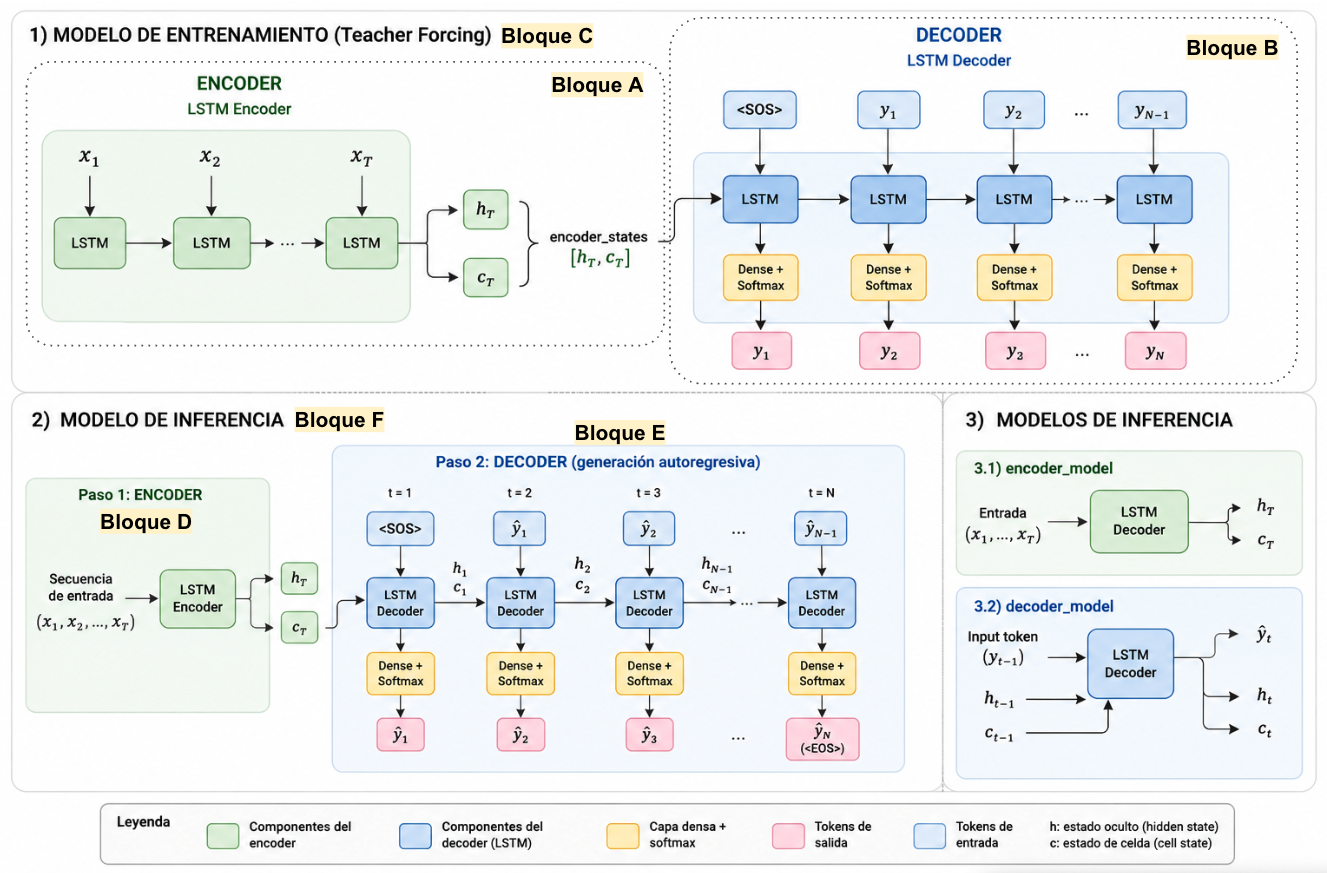

Esta función crea tres modelos en uno:
* `model`           : modelo COMPLETO de entrenamiento
* `encoder_model`   : extrae el "contexto" (estados h, c)
* `decoder_model`   : genera la secuencia de salida token a token

Los parámetros para esta función son:
* n_input  : dimensión del vocab de entrada (VOCAB_SIZE)
* n_output : dimensión del vocab de salida  (VOCAB_SIZE)
* n_units  : neuronas ocultas en la LSTM

In [ ]:
def construir_modelos(n_input, n_output, n_units=128):

    # ENCODER (Bloque A)
    # Recibe la secuencia de entrada (de cualquier longitud, por eso None) y produce un "resumen" (estados h, c)
    encoder_input  = Input(shape=(None, n_input))          # secuencia variable
    _, state_h, state_c = LSTM(n_units, return_state=True)(encoder_input)
    encoder_states = [state_h, state_c]                    # "contexto" aprendido

    # DECODER (compartido entre entrenamiento e inferencia) (Bloque B)
    # La misma capa LSTM se reutiliza en ambas fases
    decoder_input = Input(shape=(None, n_output))
    decoder_lstm  = LSTM(n_units, return_sequences=True, return_state=True)
    decoder_dense = Dense(n_output, activation='softmax')

    # En ENTRENAMIENTO: el decoder toma los estados del encoder
    dec_out, _, _ = decoder_lstm(decoder_input, initial_state=encoder_states)
    dec_out       = decoder_dense(dec_out)

    # MODELO DE ENTRENAMIENTO (Bloque C)
    model = Model(inputs=[encoder_input, decoder_input], outputs=dec_out)

    # MODELO DE INFERENCIA: ENCODER (Bloque D)
    # Dado un input, devuelve solo los estados (el "contexto")
    encoder_model = Model(inputs=encoder_input, outputs=encoder_states)

    # MODELO DE INFERENCIA: DECODER (Bloque E)
    # En inferencia generamos token a token, así que necesitamos
    # pasar los estados explícitamente en cada paso
    inf_state_h = Input(shape=(n_units,))   # estado h del paso anterior
    inf_state_c = Input(shape=(n_units,))   # estado c del paso anterior
    inf_states_in = [inf_state_h, inf_state_c]

    inf_dec_out, new_h, new_c = decoder_lstm(decoder_input, initial_state=inf_states_in)
    inf_dec_out = decoder_dense(inf_dec_out)


    decoder_model = Model(
        inputs  = [decoder_input] + inf_states_in,
        outputs = [inf_dec_out, new_h, new_c]
    )

    return model, encoder_model, decoder_model

In [ ]:
IN_DIM  = X1.shape[-1]      # = VOCAB_SIZE
OUT_DIM = target.shape[-1]  # = VOCAB_SIZE

model, encoder_model, decoder_model = construir_modelos(IN_DIM, OUT_DIM, n_units=64)
model.compile(loss='categorical_crossentropy', optimizer='adam')

### **Entrenamiento**

Entrenamos el modelo

Debes obtener un loss menor ó igual a 0.07

In [ ]:
hist = model.fit(
    [X1, X2], target,
    epochs=150,
    batch_size=5,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - loss: 4.1542 - val_loss: 4.1294
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 4.1425 - val_loss: 4.1279
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.1308 - val_loss: 4.1285
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4.1192 - val_loss: 4.1307
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 4.1074 - val_loss: 4.1337
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 4.0952 - val_loss: 4.1372
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.0828 - val_loss: 4.1411
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.0700 - val_loss: 4.1456
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.0559 - val_loss: 4.1507
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4.0420 - val_loss: 4.1560
Epoch 11/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.0264 - val_loss: 4.1617
Epoch 12/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4.0090 - val_l

Visualizamos loss de entrenamiento y validación

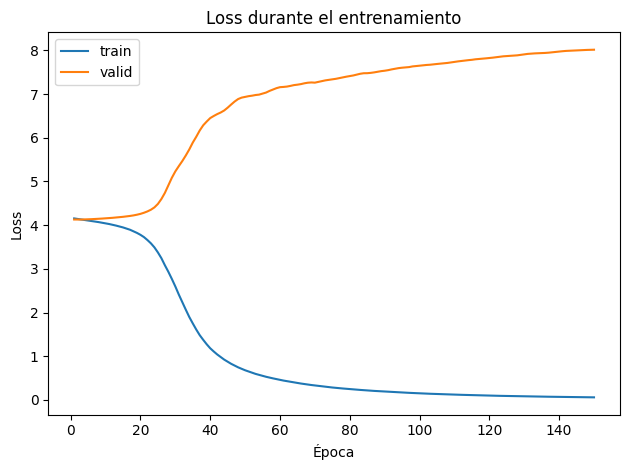

In [ ]:
epoch_count = range(1, len(hist.history['loss']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['loss'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_loss'], label='valid')
plt.title("Loss durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

### **Inferencia**

Definimos función para convertir secuencias OHE a lista de valores originales

In [ ]:
def decodificar_ohe(seq_ohe, label_encoder):
    indices = [np.argmax(v) for v in seq_ohe]
    return label_encoder.inverse_transform(indices)

Definimos función para generar secuencia de salida usando el encoder-decoder en inferencia

In [ ]:
# (Bloque F)
def predecir(x_seq, encoder_model, decoder_model, label_encoder, vocab_size, n_steps=3):
    # Paso 1: obtener contexto del encoder
    states = encoder_model.predict(x_seq, verbose=0)

    # Paso 2: primer token del decoder = <sos> (índice 0)
    token = to_categorical(0, num_classes=vocab_size).reshape(1, 1, vocab_size)

    output = []
    for _ in range(n_steps):
        # Predice el siguiente token usando el token actual y los estados
        pred, h, c = decoder_model.predict([token] + states, verbose=0)

        output.append(pred[0])      # guardamos la distribución predicha

        # Actualizamos para el siguiente paso (auto-regresión)
        states = [h, c]             # nuevos estados
        token  = pred               # token predicho → nueva entrada

    return output

Realizamos pruebas

In [ ]:
x_test = [20, 25, 30]
y_test = [x + 15 for x in x_test]

In [ ]:
X1_test, X2_test, target_test = preparar_dataset(
    np.array([x_test]), np.array([y_test]), label_encoder, VOCAB_SIZE
)

In [ ]:
output = predecir(X1_test, encoder_model, decoder_model, label_encoder, VOCAB_SIZE)

In [ ]:
print("\nEsperado:", y_test)
print("Predicho:", list(decodificar_ohe(output, label_encoder)))


Esperado: [35, 40, 45]
Predicho: [np.int64(35), np.int64(40), np.int64(45)]


Debes obtener un loss menor a 0.10

In [ ]:
loss = model.evaluate([X1_test, X2_test], target_test, verbose=0)
print(f"Loss en test: {loss:.4f}")

Loss en test: 0.0731
